In [17]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import polars as pl
import seaborn as sns
import spacy
import re
import unicodedata

from collections import Counter
from lightgbm import LGBMClassifier
from scipy.stats import kurtosis, skew, spearmanr
from sklearn.decomposition import NMF, LatentDirichletAllocation
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from typing import Dict
from xgboost import XGBRegressor, XGBClassifier
from wordcloud import WordCloud

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.style.use("tableau-colorblind10")

pl.Config.set_tbl_rows(-1)
pl.Config.set_tbl_cols(-1)
pl.Config.set_tbl_width_chars(200)

# similar to Swift's extension
@pl.api.register_dataframe_namespace("stats")
class StatsExtension:
    def __init__(self, df):
        self._df = df

    def describe_extended(self):
        numeric_cols = [c for c in self._df.columns if self._df[c].dtype.is_numeric()]
        data = self._df.select(numeric_cols)
        
        stats_df = data.describe()
        skew_row = pl.DataFrame([{"statistic": "skew", **dict(zip(numeric_cols, skew(data.to_numpy())))}])
        kurt_row = pl.DataFrame([{"statistic": "kurtosis", **dict(zip(numeric_cols, kurtosis(data.to_numpy())))}])
        
        return pl.concat([stats_df, skew_row, kurt_row])
    
def does_contain_duplicate_unique_feature(data, unique_feature):
    return data.select(pl.col(unique_feature)).n_unique() != data.shape[0]

def strip_combining(text):
    return "".join(c for c in unicodedata.normalize("NFD", text) if unicodedata.category(c) != "Mn")

def plot_bar_chart(data, feature):
    rc = data.group_by(feature).len().sort(feature)
    total = rc["len"].sum()
    rc = rc.with_columns(
        (pl.col("len") / total * 100).alias("percent")
    )

    plt.figure()
    plt.bar(rc[feature], rc["len"])
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.title(f"{feature} Bar Chart")
    plt.show()
    
    for row in rc.iter_rows(named=True):
        print(f"Rating {row[feature]}: {row['percent']:.2f}%")
        
def plot_histogram(data, feature):
    vals = data.select(pl.col(feature)).to_numpy()

    plt.hist(vals, bins=50)
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {feature}")
    plt.show()

def plot_box_violin(data, feature_1, feature_2):
    pdf = data.select([feature_1, feature_2]).to_pandas()

    ratings = sorted(pdf[feature_1].unique())
    data_groups = [pdf[pdf[feature_1] == r][feature_2] for r in ratings]

    fig, axes = plt.subplots(1, 2)

    # Boxplot
    axes[0].boxplot(data_groups)
    axes[0].set_title("Boxplot")
    axes[0].set_xlabel(feature_1)
    axes[0].set_ylabel(feature_2)
    axes[0].set_xticks(range(1, len(ratings)+1))
    axes[0].set_xticklabels(ratings)

    # Violin plot
    axes[1].violinplot(data_groups)
    axes[1].set_title("Violin Plot")
    axes[1].set_xlabel(feature_1)
    axes[1].set_ylabel(feature_2)
    axes[1].set_xticks(range(1, len(ratings)+1))
    axes[1].set_xticklabels(ratings)
    
    for ax in axes:
        ax.tick_params(axis='x', rotation=45)
        ax.set_xlabel(feature_1)

    plt.tight_layout()
    plt.show()

/var/folders/8w/84rdhw3927qc3wc2q357m96r0000gn/T/ipykernel_18222/2230355095.py:37: UserWarning: overriding existing custom namespace 'stats' (on DataFrame)
  class StatsExtension:


In [18]:
data = pl.read_csv("./data/Amazon_Reviews.csv") # https://www.kaggle.com/datasets/dongrelaxman/amazon-reviews-dataset

In [19]:
# =============================================================================
# PART 1: EDA
# =============================================================================

def eda_reviews(df: pl.DataFrame):
    """Explore the Amazon reviews dataset."""
    print("=" * 60)
    print("AMAZON REVIEWS EDA")
    print("=" * 60)
    print(f"Shape: {df.shape}")
    print(f"\nContains duplicate Profile Link: {does_contain_duplicate_unique_feature(df, 'Profile Link')}")
    print(f"\nMissing values:\n{df.null_count()}")
    print(f"\nCountry distribution:\n{df.group_by('Country').len().sort('len', descending=True).head(10)}")
    
    # --- Parse rating from string like "Rated 1 out of 5 stars" ---
    # extract numeric features
    df = df.with_columns(
        pl.col("Review Count").str.extract(r"(\d)", 1).cast(pl.Int64).alias("Review Count Num"),
        pl.col("Rating").str.extract(r"(\d)", 1).cast(pl.Int64).alias("Rating Num")
    )
    
    # clean string data
    df = df.with_columns(
        pl.col("Review Title")
            .map_elements(strip_combining, return_dtype=pl.String) # removes non-ASCII
            .str.replace_all(r"\s+", " ")
            .str.strip_chars()
            .alias("Review Title Clean"), # removes whitespace
        pl.col("Review Text")
            .map_elements(strip_combining, return_dtype=pl.String) # removes non-ASCII
            .str.replace_all(r"\s+", " ")
            .str.strip_chars()
            .alias("Review Text Clean") # removes whitespace
    )

    df = df.with_columns(
        pl.col("Review Title Clean").str.len_chars().alias("Title Char Count"),
        pl.col("Review Title Clean").str.split(" ").list.len().alias("Title Word Count"),
        pl.col("Review Text Clean").str.len_chars().alias("Review Char Count"),
        pl.col("Review Text Clean").str.split(" ").list.len().alias("Review Word Count"),
    )

    df = df.with_columns([
        (pl.col("Review Char Count") / pl.col("Review Word Count")).alias("Avg Word Length"),
        (pl.col("Review Word Count") / pl.col("Title Word Count")).alias("Review to Title Words")
    ])
    
    # remove rubbish
    df = df.filter(
        (pl.col("Review Word Count") > 3) &         # too short = useless
        (pl.col("Avg Word Length") < 15)            # no real English word is 15+ chars avg
    )
    
    print(f"\nStats:\n{df.stats.describe_extended()}")
    
    # --- Rating distribution ---
    # plot bar chart of rating_num value counts
    plot_bar_chart(df, "Rating Num")
    
    # --- Review Char Count ---
    # plot distribution of Review Char Count
    # plot Review Char Count vs Rating Num (boxplot or violin plot)
    plot_histogram(df, "Review Char Count")
    
    plot_box_violin(df, "Rating Num", "Review Char Count")
    
    # --- Review Count ___
    # does review count affect rating
    plot_box_violin(df, "Rating Num", "Review Count Num")
    pdf = df.to_pandas()
    print(pdf.groupby("Rating Num")["Review Count Num"].mean())
    
    # --- Reviews over time ---
    # parse 'Date of Experience' to datetime
    # plot review count per month over time
    df = df.with_columns(
        pl.col("Date of Experience")
        .str.strptime(pl.Date, "%B %d, %Y", strict=False)
        .alias("date")
    )
    monthly = (
        df.with_columns(pl.col("date").dt.truncate("1mo").alias("month"))
        .group_by("month")
        .len()
        .sort("month")
        .drop_nulls()
    )

    plt.figure()
    plt.plot(monthly["month"].to_list(), monthly["len"].to_list())
    plt.xlabel("Month")
    plt.ylabel("Review Count")
    plt.title("Reviews Over Time")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    monthly_by_rating = (
        df.with_columns(pl.col("date").dt.truncate("1mo").alias("month"))
        .group_by(["month", "Rating Num"])
        .len()
        .sort("month")
        .drop_nulls()
    )

    pdf = monthly_by_rating.to_pandas()
    pdf.pivot(index="month", columns="Rating Num", values="len").plot()
    plt.xlabel("Month")
    plt.ylabel("Review Count")
    plt.title("Reviews Over Time by Rating")
    plt.tight_layout()
    plt.show()

    return df

In [20]:
# =============================================================================
# PART 2: TEXT PREPROCESSING
# =============================================================================

def preprocess_text(df: pl.DataFrame):
    """
    Clean and preprocess review text using spaCy.
    
    Steps:
      1. Drop rows with missing Review Text
      2. Clean: lowercase, remove URLs, emails, special chars
      3. spaCy: tokenize, lemmatize, remove stopwords & punctuation
      4. Store cleaned text back in dataframe
    """
    nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])  # speed: only keep tokenizer + lemmatizer
    
    df = df.drop_nulls(subset=["Review Text"]).clone()
    
    # --- Basic cleaning ---
    df = df.with_columns(
        pl.col("Review Text")
        .map_elements(strip_combining, return_dtype=pl.String) # removes non-ASCII
        .str.to_lowercase()
        .str.replace_all(r"http\S+|www\S+", "")   # remove URLs
        .str.replace_all(r"\S+@\S+", "")          # remove emails
        .str.replace_all(r"[^a-zA-Z\s]", "")      # keep only letters
        .str.replace_all(r"\s+", " ")             # collapse whitespace
        .str.strip_chars()                        # trim
        .alias("clean_text")
    )
    
    # remove rubbish
    df = df.with_columns(
        pl.col("clean_text").str.len_chars().alias("text_char_count"),
        pl.col("clean_text").str.split(" ").list.len().alias("text_word_count"),
    )
    df = df.with_columns(
        (pl.col("text_char_count") / pl.col("text_word_count")).alias("avg_word_length")
    )
    df = df.filter(
        (pl.col("text_word_count") > 3) &           # too short = useless
        (pl.col("avg_word_length") < 15)            # no real English word is 15+ chars avg
    )
    
    # --- spaCy lemmatization ---
    # TODO: process texts through spaCy pipeline
    #   - use nlp.pipe(texts, batch_size=500) for efficiency
    #   - for each doc, keep tokens where:
    #       not token.is_stop
    #       not token.is_punct
    #       not token.is_space
    #       len(token.lemma_) > 2
    #   - join lemmas back into string
    
    def lemmatize_batch(texts, batch_size=500, n_process=-1):
        """Use spaCy's pipe for efficient batch processing."""
        results = []
        custom_stops = {"not", "amazon", "get", "say", "tell", "find", "buy"}
        for doc in nlp.pipe(texts, batch_size=batch_size, n_process=n_process):
            lemmas = [token.lemma_ for token in doc 
                if not token.is_stop and not token.is_punct 
                and not token.is_space and len(token.lemma_) > 2
                and token.lemma_ not in custom_stops]
            results.append(" ".join(lemmas))
        return results
    
    texts = df["clean_text"].to_list()
    lemmatized = lemmatize_batch(texts, 2000)
    df = df.with_columns(
        pl.Series("lemmatized", lemmatized)
    )
    
    # --- Word frequency analysis ---
    # TODO: split into positive (4-5 stars) and negative (1-2 stars)
    # TODO: count word frequencies for each group
    # TODO: find words that appear disproportionately in negative vs positive
    # TODO: WordCloud for positive and negative reviews side by side
    
    df = df.with_columns(
        pl.col("Rating").str.extract(r"(\d)", 1).cast(pl.Int64).alias("rating_num")
    )

    df_positive = df.filter(pl.col("rating_num") > 3)
    df_negative = df.filter(pl.col("rating_num") < 3)

    # --- Word frequencies ---
    pos_words = " ".join(df_positive["lemmatized"].to_list()).split()
    neg_words = " ".join(df_negative["lemmatized"].to_list()).split()

    pos_freq = Counter(pos_words)
    neg_freq = Counter(neg_words)

    print("Top 20 positive words:")
    print(pos_freq.most_common(20))
    print("\nTop 20 negative words:")
    print(neg_freq.most_common(20))

    # --- Words disproportionately in negative vs positive ---
    all_words = set(pos_freq.keys()) | set(neg_freq.keys())
    pos_total = len(pos_words)
    neg_total = len(neg_words)

    ratios = {}
    for word in all_words:
        pos_rate = pos_freq.get(word, 0) / pos_total
        neg_rate = neg_freq.get(word, 0) / neg_total
        if neg_rate > 0 and pos_rate > 0:
            ratios[word] = neg_rate / pos_rate

    print("\nMost disproportionately negative words:")
    print(sorted(ratios.items(), key=lambda x: x[1], reverse=True)[:20])

    print("\nMost disproportionately positive words:")
    print(sorted(ratios.items(), key=lambda x: x[1])[:20])

    # --- Word Clouds ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    wc_pos = WordCloud(width=800, height=400, background_color="white").generate(" ".join(pos_words))
    axes[0].imshow(wc_pos, interpolation="bilinear")
    axes[0].set_title("Positive Reviews (4-5 stars)")
    axes[0].axis("off")

    wc_neg = WordCloud(width=800, height=400, background_color="white").generate(" ".join(neg_words))
    axes[1].imshow(wc_neg, interpolation="bilinear")
    axes[1].set_title("Negative Reviews (1-2 stars)")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

    return df

In [21]:
# =============================================================================
# PART 3: TOPIC MODELING
# =============================================================================

def topic_modeling(df: pl.DataFrame, n_topics: int=8):
    """
    Extract topics from reviews using TF-IDF + NMF.
    
    NMF (Non-negative Matrix Factorization) tends to give cleaner,
    more interpretable topics than LDA for short texts like reviews.
    """
    # --- TF-IDF ---
    # TODO: create TF-IDF matrix from df["lemmatized"]
    tfidf = TfidfVectorizer(max_features=5000, min_df=5, max_df=0.85)
    tfidf_matrix = tfidf.fit_transform(df["lemmatized"])
    
    # --- NMF ---
    # TODO: fit NMF model
    nmf = NMF(n_components=n_topics, random_state=42, max_iter=500)
    topic_matrix = nmf.fit_transform(tfidf_matrix)  # (n_docs, n_topics)
    
    # --- Display topics ---
    # TODO: for each topic, show top 15 words
    feature_names = tfidf.get_feature_names_out()
    for i, topic in enumerate(nmf.components_):
        top_words = [feature_names[j] for j in topic.argsort()[-15:]]
        print(f"Topic {i}: {', '.join(top_words)}")
    
    # --- Assign dominant topic to each review ---
    # TODO: df["dominant_topic"] = topic_matrix.argmax(axis=1)
    df = df.with_columns(
        pl.Series("dominant_topic", topic_matrix.argmax(axis=1))
    )
    
    # --- Topic distribution by rating ---
    # TODO: crosstab of rating_num vs dominant_topic
    # TODO: heatmap showing which topics are most common in 1-star vs 5-star reviews
    heatmap_df = (
        df.group_by(["rating_num", "dominant_topic"])
        .len()
        .pivot(
            values="len",
            index="dominant_topic",
            on="rating_num",
            aggregate_function="first"
        )
        .sort("dominant_topic")
    )

    pdf = heatmap_df.to_pandas().set_index("dominant_topic")
    sns.heatmap(pdf, annot=True, fmt=".0f", cmap="YlOrRd")
    plt.xlabel("Rating")
    plt.ylabel("Topic")
    plt.title("Topic Distribution by Rating")
    plt.show()
    
    # --- Manually label topics ---
    # After seeing the top words, create a mapping like:
    #   topic_labels = {0: "shipping", 1: "product_quality", 2: "customer_service", ...}
    # TODO: df["topic_label"] = df["dominant_topic"].map(topic_labels)
    
    topic_labels = {
        0: "returns_refunds",
        1: "review_integrity",
        2: "shopping_experience",
        3: "prime_subscriptions",
        4: "customer_service",
        5: "positive_praise",
        6: "billing_accounts",
        7: "package_delivery",
    }
    df = df.with_columns(
        pl.col("dominant_topic").cast(pl.String).replace(topic_labels, return_dtype=pl.String).alias("topic_label")
    )
    
    return df

In [22]:
# =============================================================================
# PART 4: SENTIMENT CLASSIFICATION
# =============================================================================
def get_label_balance(label_column: pd.Series, labels_dict: Dict[int, Dict[str, str]], should_return_label_counts=False) -> pd.Series:
        label_counts = label_column.value_counts().sort_index(ascending=True)
        num_labels = len(labels_dict.keys())
        labels = [f"{labels_dict.get(i).get('name')} {label_counts.loc[i]}" for i in range(num_labels)]
        cmap = plt.get_cmap('Set3')
        colors = [cmap(i / num_labels) for i in range(num_labels)]
        plt.figure(figsize=(12, 10))
        plt.pie(label_counts, labels=labels, autopct='%1.1f%%', colors=colors, explode=[0.05, 0])
        plt.title('Reviews Labels Balance')
        plt.axis('equal')
        plt.tight_layout()
        plt.show()
        return label_counts if should_return_label_counts else None
    
def get_optimized_params(model: str, 
                         X_train: pd.DataFrame, 
                         y_train: pd.Series,
                         scoring: str='accuracy',
                         should_randomize: bool=False,
                         trials: int=100):
    random_seed = None if should_randomize else 42
    def objective(trial):
        match model:
            case 'lr':
                penalty = trial.suggest_categorical('penalty', ['l1', 'l2'])
                C = trial.suggest_float('C', 1e-4, 1e2)
                solver = 'liblinear' if penalty == 'l1' else trial.suggest_categorical('solver', ['lbfgs', 'saga', 'liblinear'])
                max_iter = trial.suggest_int('max_iter', 100, 10000)
                clf = LogisticRegression(penalty=penalty, C=C,  solver=solver, max_iter=max_iter, random_state=random_seed, n_jobs=1)
            case 'svc':
                C = trial.suggest_float('C', 0.001, 100, log=True)
                kernel = trial.suggest_categorical('kernel', ['linear', 'rbf', 'poly', 'sigmoid'])
                gamma = trial.suggest_float('gamma', 0.0001, 10, log=True) if kernel != 'linear' else 'auto'
                degree = trial.suggest_int('degree', 2, 5) if kernel == 'poly' else 3
                max_iter = trial.suggest_int('max_iter', 100, 10000)
                clf = SVC(C=C, kernel=kernel, gamma=gamma, degree=degree, max_iter=max_iter, probability=True, random_state=random_seed)
            case _:
                print(model, 'is not a valid model')
                return
                
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_seed)
        score = cross_val_score(clf, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
        return score.mean()
    
    # Run Optuna optimization
    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=random_seed))
    study.optimize(objective, n_trials=trials)

    # Show best result
    trial = study.best_trial
    print("Best trial:")
    print(f"{scoring}: {trial.value}")
    print("Best hyperparameters: ", trial.params)

    # Train and test the best model
    return trial.value, trial.params

def get_model(model: str, params):
    match model:
        case 'lr':
            if params.get('penalty') == 'l1' and not params.get('solver'):
                params['solver'] = 'liblinear'
            return LogisticRegression(**params, random_state=42, n_jobs=-1)
        case 'svc':
            return SVC(**params, probability=True, random_state=42)
        case _:
            print(model, 'is not a valid model')
            return None

def sentiment_classification(df: pl.DataFrame):
    """
    Train a classifier to predict positive/negative sentiment from review text.
    Uses star ratings as ground truth labels.
    """
    # --- Create binary labels ---
    # TODO: filter to only 1-2 star (negative) and 4-5 star (positive)
    # TODO: drop 3-star reviews (ambiguous)
    df_binary = df.filter(
        pl.col('rating_num').is_in([1,2,4,5])
    )
    
    df_binary = df_binary.with_columns(
        (pl.col('rating_num') >= 4).alias('label').cast(pl.Int8)
    )
    
    # --- TF-IDF features ---
    # TODO: vectorize lemmatized text
    tfidf = TfidfVectorizer(max_features=5000, min_df=3, max_df=0.9)
    X = tfidf.fit_transform(df_binary["lemmatized"])
    y = df_binary["label"].to_pandas()
    
    labels_dict = {
        0: {
            'name': 'Negative',
            'color': 'r',
            'marker': '^'
        },
        1: {
            'name': 'Positive',
            'color': 'b',
            'marker': 'o'
        }
    }
    
    get_label_balance(y, labels_dict)
    
    # --- Train/test split ---
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    
    # --- Logistic Regression ---
    # TODO: train models
    # TODO: print classification_report
    # TODO: plot confusion matrix
    # --- Train models ---
    models = ['lr', 'svc']
    results = {}
    for model_name in models:
        score, params = get_optimized_params(model_name, X_train, y_train, 'accuracy', False, 50)
        clf = get_model(model_name, params)
        clf.fit(X_train, y_train)
        preds = clf.predict(X_test)
        results[model_name] = {
            'model': clf,
            'params': params,
            'prediction': preds,
            'accuracy': accuracy_score(y_test, preds),
            'f1': f1_score(y_test, preds),
        }
        print(f"\n{'='*40}")
        print(f"{model_name.upper()}")
        print(f"Accuracy: {results[model_name]['accuracy']:.4f}")
        print(f"F1:       {results[model_name]['f1']:.4f}")
        print(classification_report(y_test, preds, target_names=["Negative", "Positive"]))

    # --- Comparison table ---
    comparison = pd.DataFrame({
        name: {'accuracy': r['accuracy'], 'f1': r['f1']}
        for name, r in results.items()
    }).T.sort_values('f1', ascending=False)
    print("\nModel Comparison:")
    print(comparison)

    # --- Confusion matrices ---
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    for ax, (name, r) in zip(axes.ravel(), results.items()):
        cm = confusion_matrix(y_test, r['prediction'])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=["Neg", "Pos"], yticklabels=["Neg", "Pos"])
        ax.set_title(f"{name.upper()} (F1={r['f1']:.3f})")
        ax.set_ylabel("Actual")
        ax.set_xlabel("Predicted")
    plt.tight_layout()
    plt.show()

    # --- Feature importance (from best linear model) ---
    for model_name in results:
        model = results[model_name]['model']
        if hasattr(model, 'coef_'):
            coefs = model.coef_[0]
            if hasattr(coefs, 'toarray'):
                coefs = coefs.toarray().ravel()
                feature_names = tfidf.get_feature_names_out()

                top_n = 20
                top_pos_idx = coefs.argsort()[-top_n:]
                top_neg_idx = coefs.argsort()[:top_n]

                fig, axes = plt.subplots(1, 2, figsize=(14, 6))

                axes[0].barh(
                    [feature_names[i] for i in top_neg_idx],
                    [coefs[i] for i in top_neg_idx],
                    color='salmon'
                )
                axes[0].set_title("Top 20 Negative Predictors")
                axes[0].set_xlabel("Coefficient")

                axes[1].barh(
                    [feature_names[i] for i in top_pos_idx],
                    [coefs[i] for i in top_pos_idx],
                    color='steelblue'
                )
                axes[1].set_title("Top 20 Positive Predictors")
                axes[1].set_xlabel("Coefficient")

                plt.tight_layout()
                plt.show()

    return df, results

AMAZON REVIEWS EDA
Shape: (21055, 9)

Contains duplicate Profile Link: False

Missing values:
shape: (1, 9)
┌───────────────┬──────────────┬─────────┬──────────────┬─────────────┬────────┬──────────────┬─────────────┬────────────────────┐
│ Reviewer Name ┆ Profile Link ┆ Country ┆ Review Count ┆ Review Date ┆ Rating ┆ Review Title ┆ Review Text ┆ Date of Experience │
│ ---           ┆ ---          ┆ ---     ┆ ---          ┆ ---         ┆ ---    ┆ ---          ┆ ---         ┆ ---                │
│ u32           ┆ u32          ┆ u32     ┆ u32          ┆ u32         ┆ u32    ┆ u32          ┆ u32         ┆ u32                │
╞═══════════════╪══════════════╪═════════╪══════════════╪═════════════╪════════╪══════════════╪═════════════╪════════════════════╡
│ 0             ┆ 0            ┆ 0       ┆ 0            ┆ 0           ┆ 0      ┆ 0            ┆ 0           ┆ 0                  │
└───────────────┴──────────────┴─────────┴──────────────┴─────────────┴────────┴──────────────┴───────────

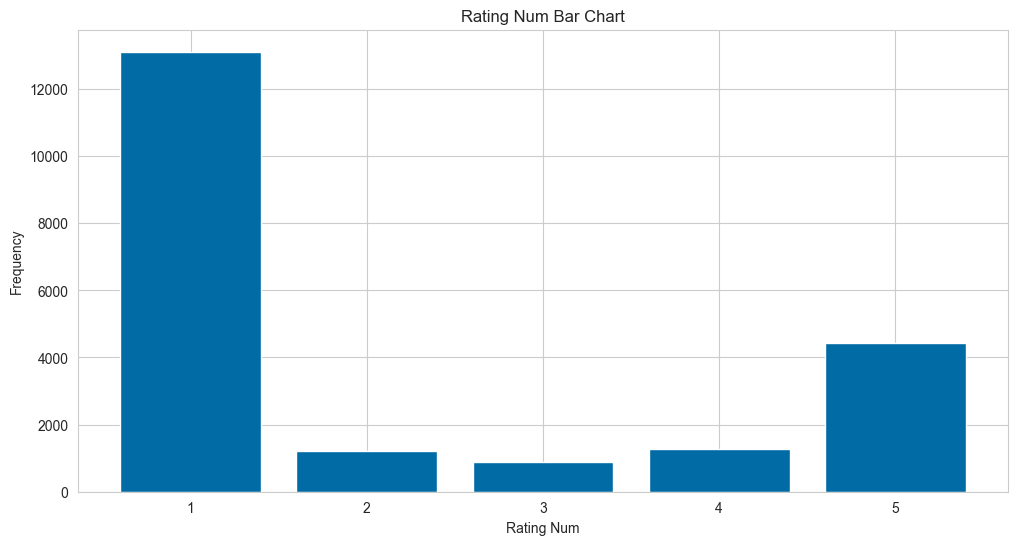

Rating 1: 62.72%
Rating 2: 5.84%
Rating 3: 4.19%
Rating 4: 6.08%
Rating 5: 21.19%


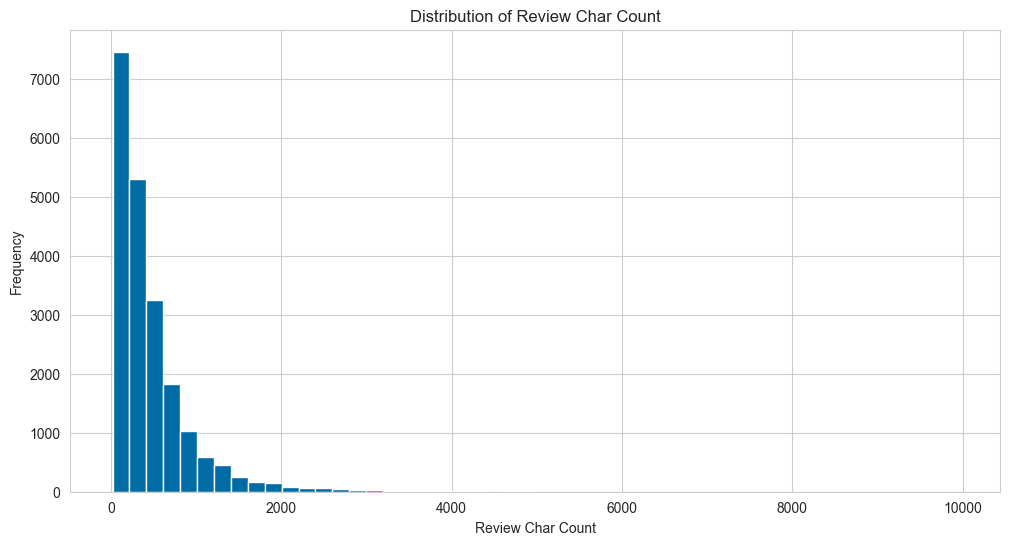

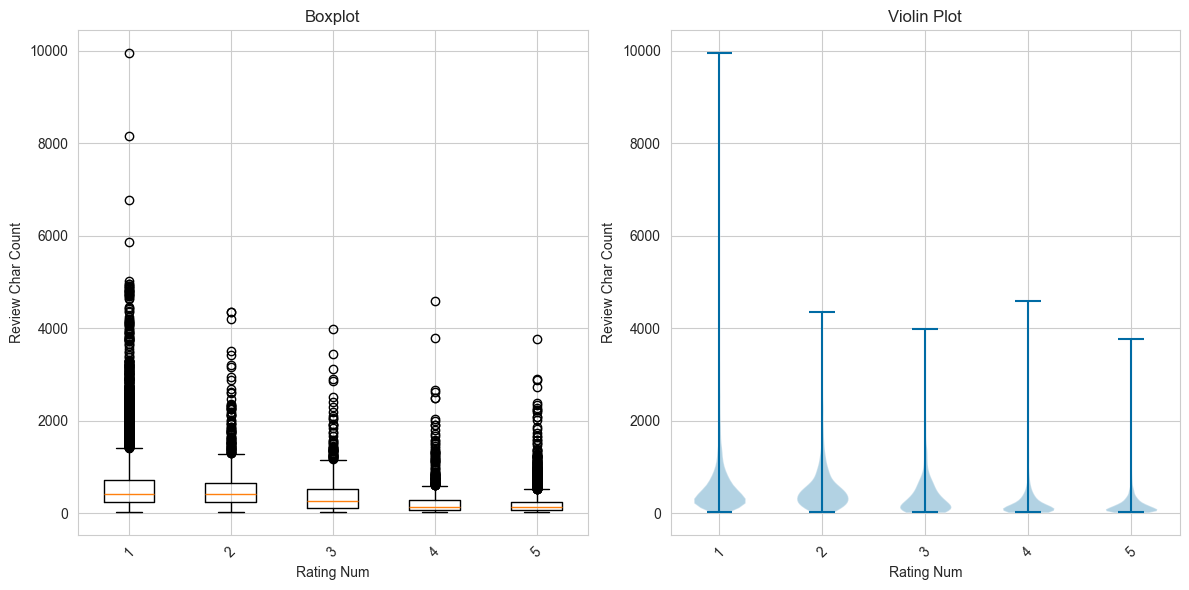

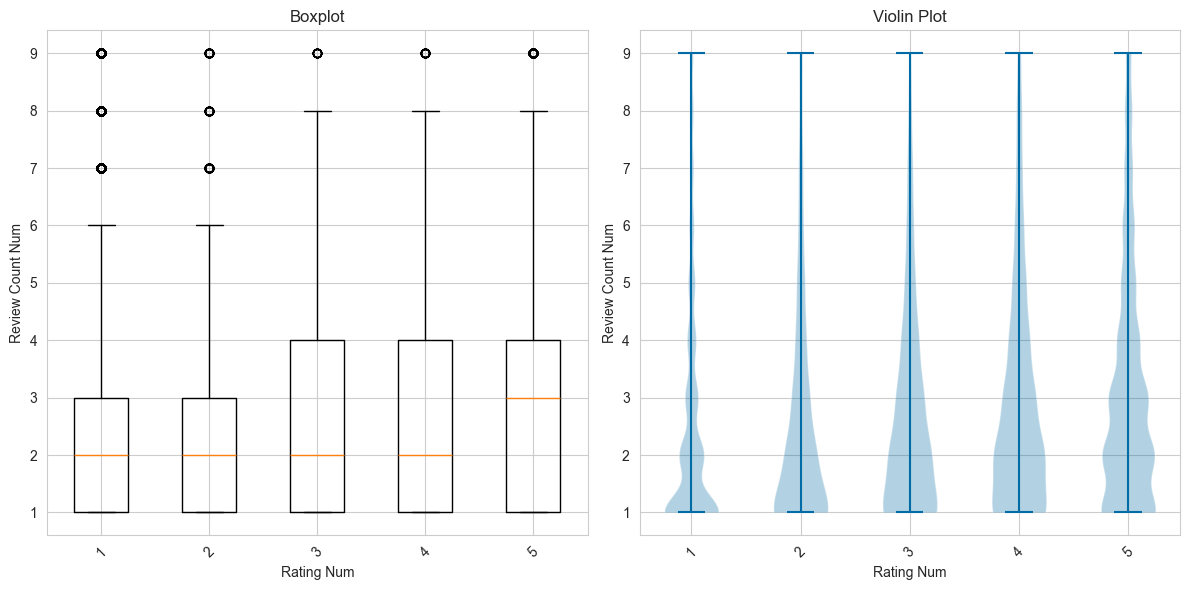

Rating Num
1    2.617420
2    2.578689
3    2.723429
4    2.926772
5    3.142696
Name: Review Count Num, dtype: float64


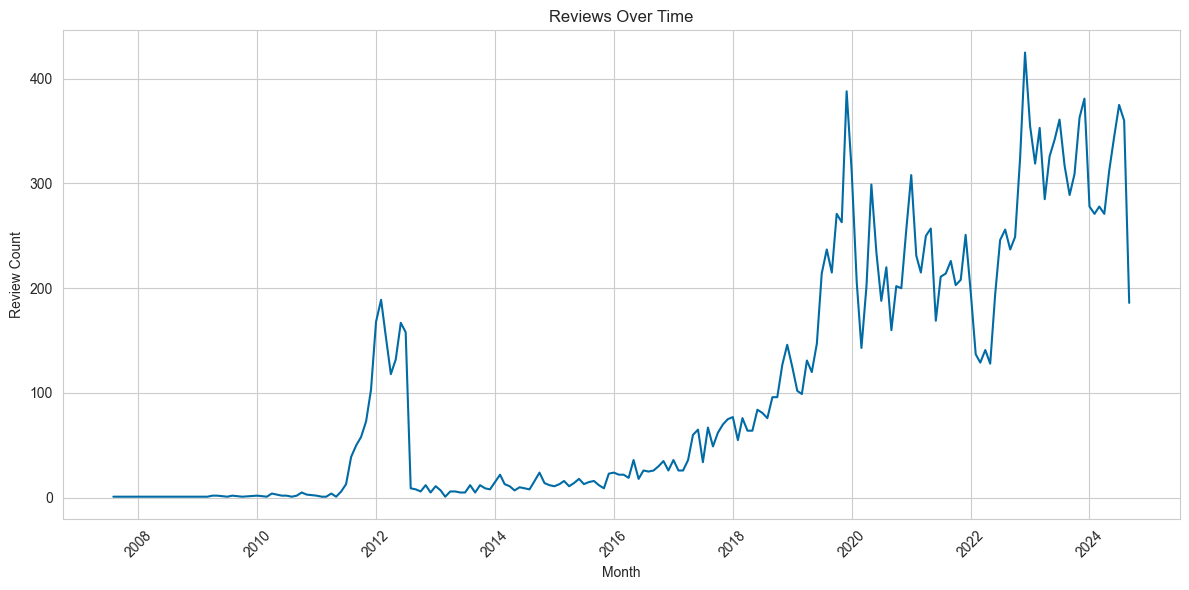

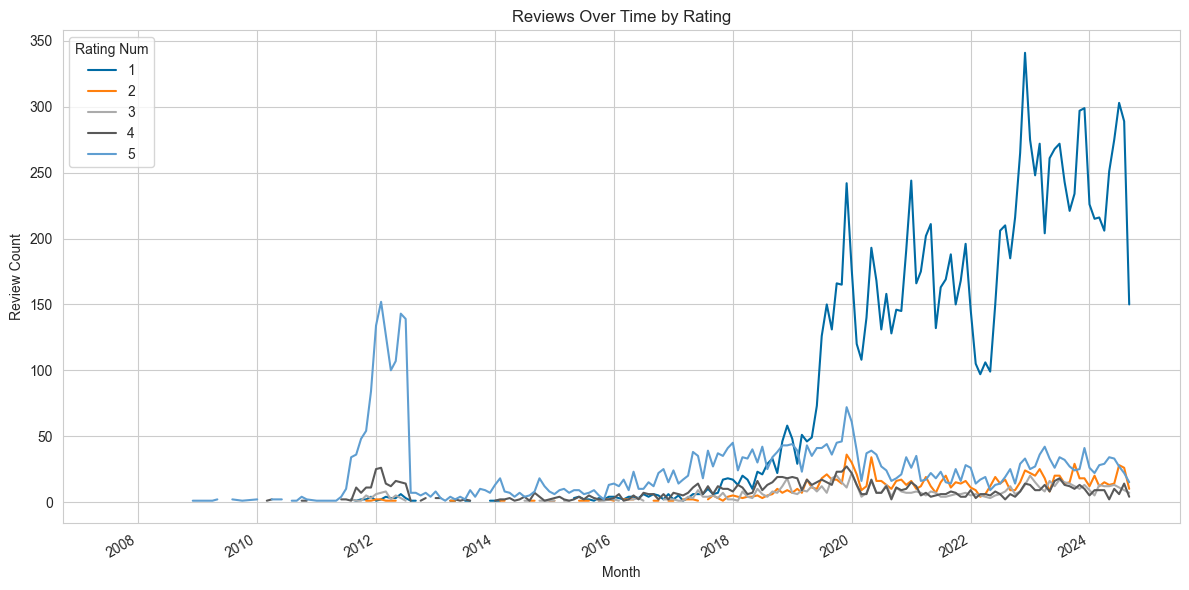

Top 20 positive words:
[('service', 2019), ('good', 1899), ('customer', 1530), ('order', 1438), ('great', 1322), ('time', 1282), ('delivery', 1258), ('item', 1171), ('product', 1124), ('prime', 980), ('price', 888), ('review', 838), ('love', 822), ('day', 789), ('problem', 750), ('company', 734), ('return', 685), ('issue', 638), ('fast', 615), ('year', 611)]

Top 20 negative words:
[('customer', 10576), ('order', 10152), ('service', 9171), ('item', 8247), ('delivery', 6855), ('day', 6846), ('time', 6689), ('refund', 5356), ('account', 5153), ('deliver', 5064), ('prime', 4491), ('return', 3963), ('receive', 3741), ('money', 3741), ('company', 3708), ('product', 3590), ('send', 3356), ('package', 3354), ('card', 3243), ('try', 3133)]

Most disproportionately negative words:
[('supervisor', 43.60618752191049), ('disgusting', 38.82846610646639), ('resident', 34.884950017528396), ('police', 32.989028820923586), ('fraudulent', 26.69457044819564), ('august', 25.481180882368562), ('june', 24.1

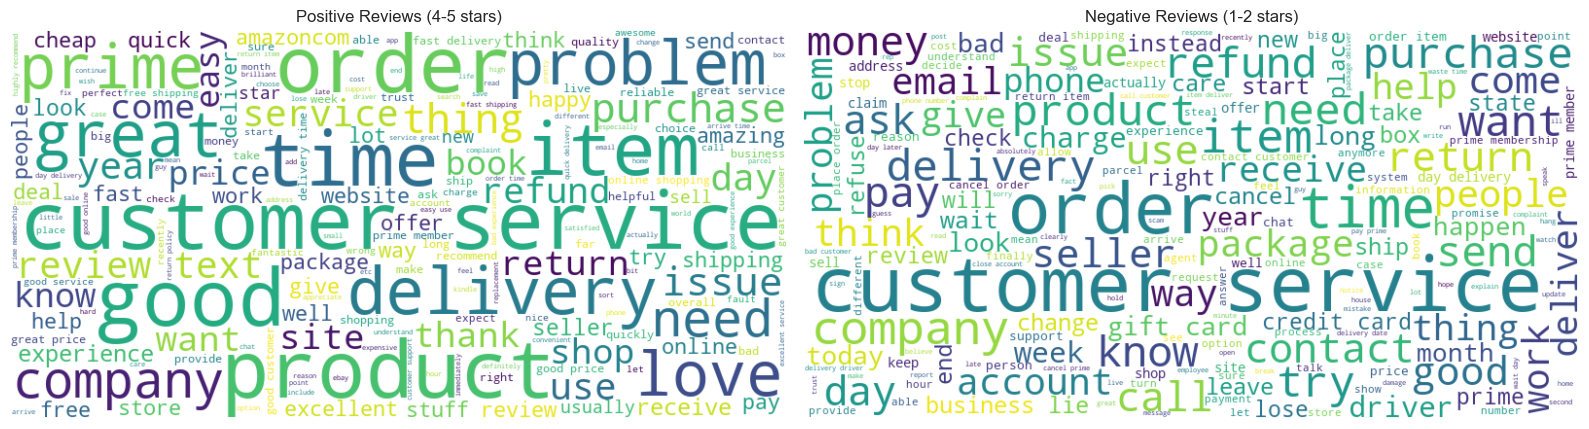

Topic 0: wait, week, issue, wrong, contact, purchase, money, order, product, send, seller, receive, return, refund, item
Topic 1: read, remove, bad, star, seller, allow, fake, honest, leave, negative, write, post, product, review, text
Topic 2: like, time, easy, website, company, site, quality, fast, shop, experience, shopping, online, price, product, good
Topic 3: late, wait, week, free, member, membership, arrive, ship, time, pay, shipping, cancel, prime, order, day
Topic 4: poor, time, chat, speak, problem, terrible, year, experience, care, help, issue, company, bad, customer, service
Topic 5: amazing, free, deal, use, site, shop, service, delivery, shipping, easy, product, fast, love, price, great
Topic 6: number, use, close, call, purchase, phone, try, bank, money, credit, email, charge, gift, card, account
Topic 7: wait, instruction, hand, day, home, house, address, time, door, leave, parcel, driver, package, deliver, delivery


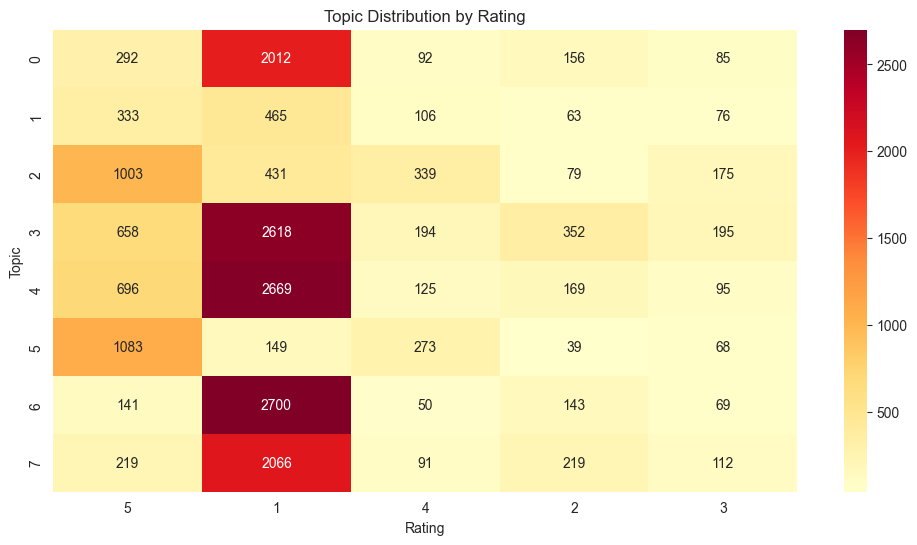

/var/folders/8w/84rdhw3927qc3wc2q357m96r0000gn/T/ipykernel_18222/2249890897.py:73: DeprecationWarning: the `return_dtype` parameter for `replace` is deprecated. Use `replace_strict` instead to set a return data type while replacing values.
(Deprecated in version 1.0.0)
  pl.col("dominant_topic").cast(pl.String).replace(topic_labels, return_dtype=pl.String).alias("topic_label")


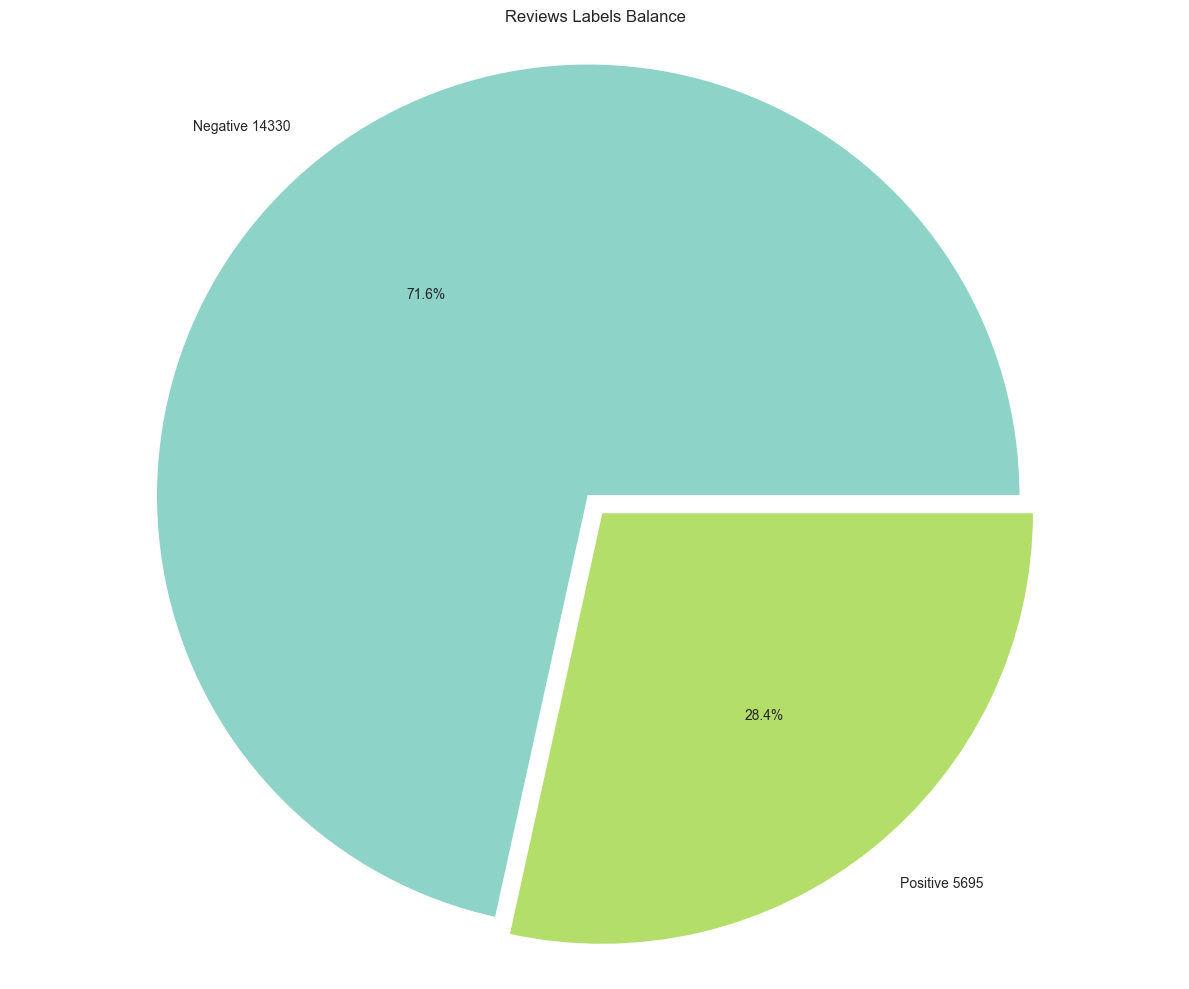

[I 2026-04-20 04:19:18,216] A new study created in memory with name: no-name-afec1cf5-6617-47ce-ab30-86aa3711d3ac
[I 2026-04-20 04:19:19,951] Trial 0 finished with value: 0.9200374531835205 and parameters: {'penalty': 'l2', 'C': 73.19942098174633, 'solver': 'lbfgs', 'max_iter': 675}. Best is trial 0 with value: 0.9200374531835205.
[I 2026-04-20 04:19:21,319] Trial 1 finished with value: 0.8976903870162298 and parameters: {'penalty': 'l1', 'C': 70.80728697234677, 'max_iter': 303}. Best is trial 0 with value: 0.9200374531835205.
[I 2026-04-20 04:19:22,598] Trial 2 finished with value: 0.9099250936329588 and parameters: {'penalty': 'l1', 'C': 21.233989833916546, 'max_iter': 1900}. Best is trial 0 with value: 0.9200374531835205.
[I 2026-04-20 04:19:23,808] Trial 3 finished with value: 0.9209737827715356 and parameters: {'penalty': 'l2', 'C': 52.47569068758062, 'solver': 'liblinear', 'max_iter': 1481}. Best is trial 3 with value: 0.9209737827715356.
[I 2026-04-20 04:19:24,963] Trial 4 finis

Best trial:
accuracy: 0.9335205992509362
Best hyperparameters:  {'penalty': 'l2', 'C': 3.438948672669728, 'solver': 'lbfgs', 'max_iter': 3186}

LR
Accuracy: 0.9288
F1:       0.8724
              precision    recall  f1-score   support

    Negative       0.94      0.96      0.95      2866
    Positive       0.89      0.86      0.87      1139

    accuracy                           0.93      4005
   macro avg       0.92      0.91      0.91      4005
weighted avg       0.93      0.93      0.93      4005



/opt/homebrew/anaconda3/envs/ml_dev/lib/python3.10/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1644).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/homebrew/anaconda3/envs/ml_dev/lib/python3.10/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1644).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/homebrew/anaconda3/envs/ml_dev/lib/python3.10/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1644).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/homebrew/anaconda3/envs/ml_dev/lib/python3.10/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1644).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/homebrew/anaconda3/envs/ml_dev/

Best trial:
accuracy: 0.9324594257178527
Best hyperparameters:  {'C': 0.7903696358626411, 'kernel': 'linear', 'max_iter': 2607}


/opt/homebrew/anaconda3/envs/ml_dev/lib/python3.10/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=2607).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(



SVC
Accuracy: 0.9293
F1:       0.8737
              precision    recall  f1-score   support

    Negative       0.94      0.96      0.95      2866
    Positive       0.89      0.86      0.87      1139

    accuracy                           0.93      4005
   macro avg       0.92      0.91      0.91      4005
weighted avg       0.93      0.93      0.93      4005


Model Comparison:
     accuracy        f1
svc  0.929338  0.873717
lr   0.928839  0.872369


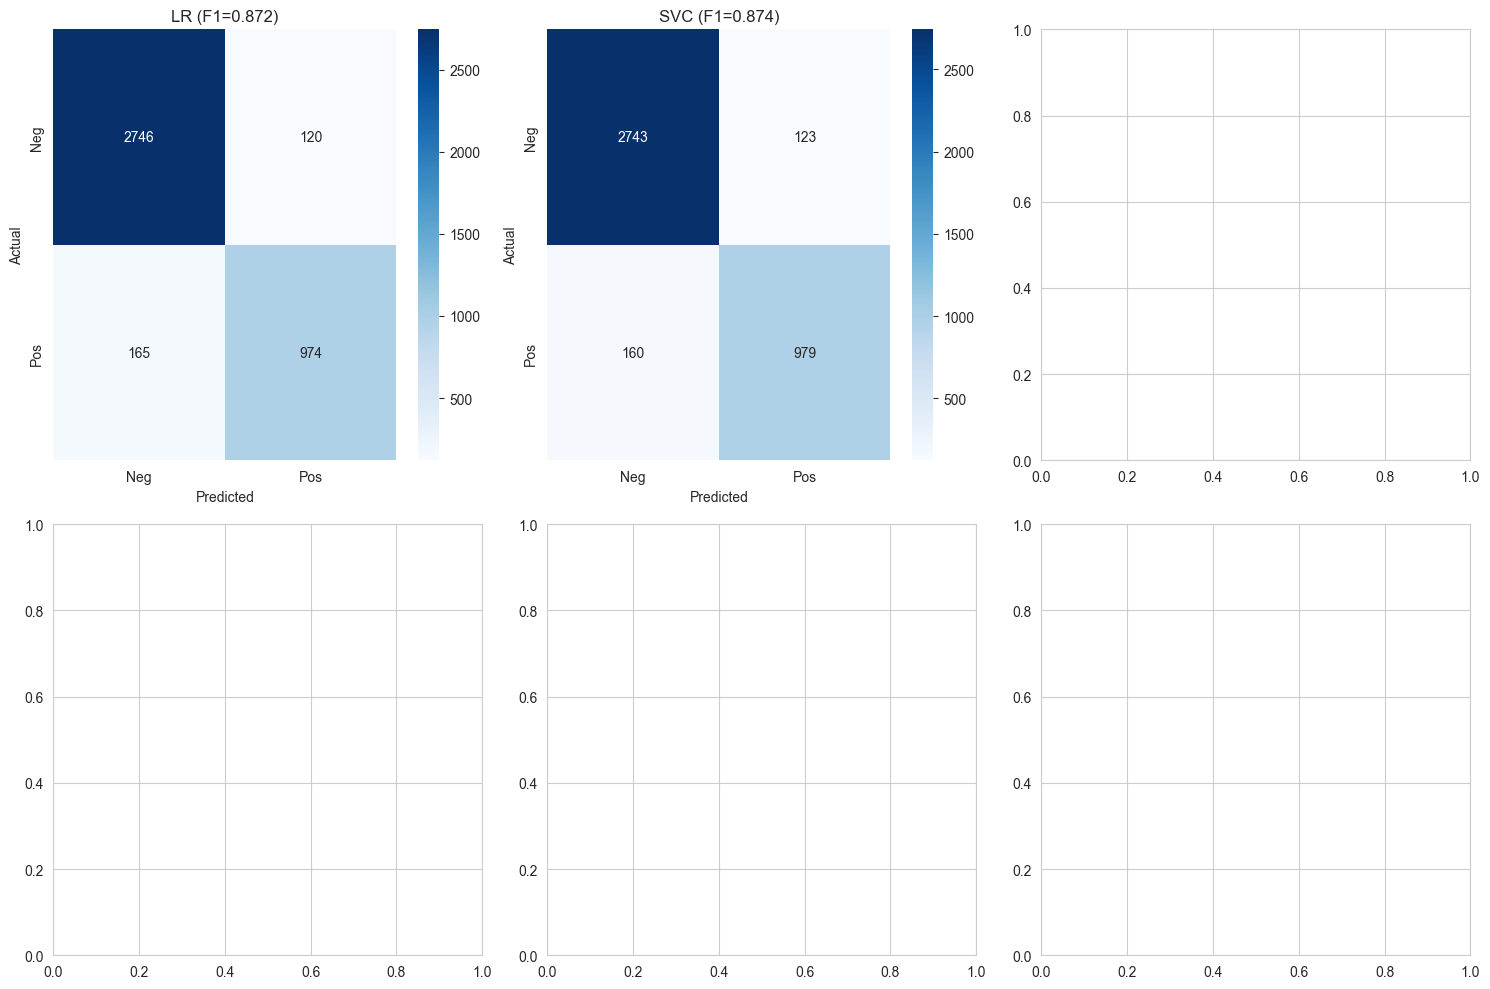

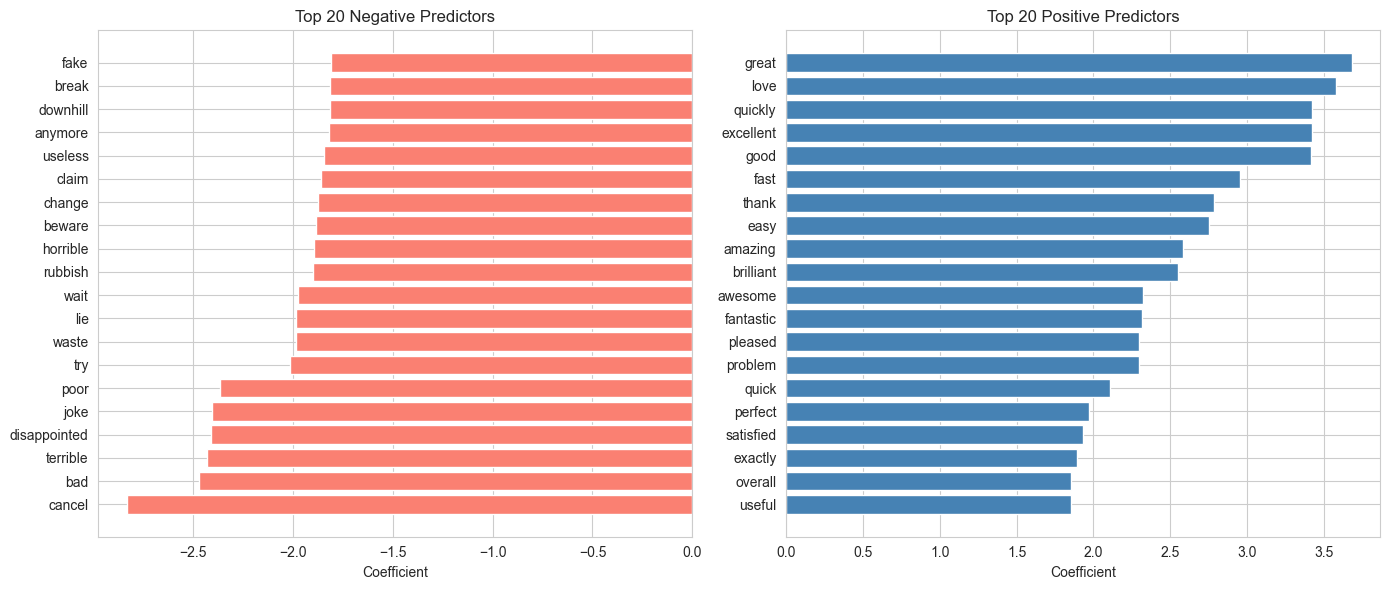

In [23]:
reviews = eda_reviews(data)
reviews = preprocess_text(reviews)
reviews = topic_modeling(reviews)
results = sentiment_classification(reviews)